### Preliminary analysis of the GRI

Using standard models for survival analysis with competing risks such Cause specific Cox PH and Fine and Grey. 

We will run it over two datasets, one would be the subset of qpis (quality measures for colorectal cancer), 
and secondly over the whole clinical data, where there are potential predictors. The dataset has been preprocessed in "prpeprocess-1.ipynb", where expert knowledge from Joanne Edwards' lab was considered to substract the relevant columns and rows, plus any further decisions taken. 

Hopefully the second dataset would allow give us hints of future qpis. 

Regarding missing values, they need to be imputed... the continuous values standarized, etc. 

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import math

# sksurv
from sksurv.util import Surv
from sksurv.linear_model import CoxPHSurvivalAnalysis

# scikit-learn
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer
from sklearn.base import clone
from sklearn.base import BaseEstimator, TransformerMixin
from pandas.api.types import is_numeric_dtype, is_categorical_dtype


# cmprsk (contains Fine and Grey model) it is and python 
# wrapper of R functions. Dependencies such r-survival are also downloaded
# Requires rpy2 library
import rpy2

# my functions 
from helper import smart_fix_dtypes
from helper import fit_cs_cox_manual
from helper import clean_columns
from helper import cifs_from_cs_hazards
from helper import fit_preprocessor

from metrics.score import CompRiskMetricsCompute
# hazardous
from metrics.score import IncidenceScoreComputer
from metrics.score import KaplanMeierIPCW


# Iterative inputer (for mice)
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import VarianceThreshold 
from sklearn.ensemble import ExtraTreesRegressor

# lifelines
from lifelines import CoxPHFitter

pd.set_option("display.max_columns", None)



### 5-fold cross-validation


We can use MICE for imputation

In [ ]:
## prepare the data

gri = pd.read_csv("data/GRI_preprocess-2.csv", index_col="TMA_Order")

gri = smart_fix_dtypes(gri, cat_threshold=10)
print(gri.shape)
# define time and status
time, status = "Disease_Free_Survival_Months", "Cmprsk_Status"

# drop if we do not know any of these two:
df = gri.dropna(subset=[time, status])

df = df.fillna(np.nan)

print(df.shape)
# create surv object 
#y = Surv.from_dataframe(time, status, df) # does not work because it expects binary
#y = Surv.from_dataframe(time, event = status > 0) 

df = df.drop(columns=["Unnamed: 0"])

# use the metadata to 
#meta = pd.read_csv("data/GRI_preprocess-1-meta.csv")
#mapping = (meta[["Data Item", "New Data Item"]]
#           .dropna()
#           .assign(**{
#               "Data Item": lambda d: d["Data Item"].astype(str).str.strip(),
#               "New Data Item": lambda d: d["New Data Item"].astype(str).str.strip()
#           })
#           .query("`New Data Item` != ''")
#           .set_index("Data Item")["New Data Item"]
#           .to_dict())

# apply
#df = df.rename(columns=mapping)

# save this to analyse some descriptive stats in R 
#df.to_csv("data/GRI_preprocess-2.csv", index=True)

#time, status = "Disease_Free_Survival_Months", "Cmprsk_Status"

#df



In [49]:
X = df.drop(columns=[time, status])
T_all = df[time].astype(float).to_numpy()
D_all = df[status].astype(int).to_numpy()

In [50]:
X.dtypes
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 722 entries, 1 to 786
Data columns (total 63 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   MMR_Status                    703 non-null    category
 1   Emergency_Surgery             722 non-null    Int8    
 2   Age                           722 non-null    float64 
 3   Sex                           722 non-null    Int8    
 4   Tumour_Location               722 non-null    category
 5   T_Stage                       722 non-null    category
 6   N_Stage                       722 non-null    category
 7   Histological_Grade            717 non-null    category
 8   Tumour_Budding                696 non-null    Int8    
 9   Tumour_Perforation            722 non-null    Int8    
 10  Margin_Invasion               722 non-null    Int8    
 11  Venous_Invasion               722 non-null    Int8    
 12  Peritoneal_Invasion           722 non-null    Int8    


In [51]:
# these are all bianry
X.select_dtypes(include="Int8").describe().columns

Index(['Emergency_Surgery', 'Sex', 'Tumour_Budding', 'Tumour_Perforation',
       'Margin_Invasion', 'Venous_Invasion', 'Peritoneal_Invasion',
       'IL6R_AK_186_64', 'ZEB1_Nuclear', 'Twist_Cytoplasmic', 'Twist_Nuclear',
       'Snail_Cytoplasmic', 'Snail_Nuclear', 'SOX9_Cytoplasmic',
       'SOX9_Nuclear', 'ZEB1_Cytoplasmic', 'BudCohort_ZEB1_Cytoplasmic_A',
       'BudCohort_ZEB1_Nuclear', 'IL17RA_Presence', 'BRAF', 'KRAS', 'NRAS'],
      dtype='object')

In [52]:
X.select_dtypes(include="category").describe().columns

Index(['MMR_Status', 'Tumour_Location', 'T_Stage', 'N_Stage',
       'Histological_Grade', 'Elastica_Venous_Invasion'],
      dtype='object')

### Cross validation

We can use a stratified 5cv fold so that we preserve the proportions of causes by fold. 

In [53]:
# init object cv
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(cv.get_n_splits())  


5


In [54]:
# generate the splits based on the causes D
splits = list(cv.split(np.arange(len(df)), y=D_all))
len(splits[0][0]) 


577

Each fold having similar proportions of causes, as well as train and sets

In [55]:
for fold, (train_idx, val_idx) in enumerate(splits, 1):
    print(f"Fold number: {fold}")
    print(f"Length of training set: {len(train_idx)}")
    print(f"Length of test set: {len(val_idx)}")

    vals, counts = np.unique(D_all[train_idx], return_counts=True)
    pct = counts / counts.sum() * 100

    print(f"Training set proportion of each cause: {pct}")

    vals, counts = np.unique(D_all[val_idx], return_counts=True)
    pct = counts / counts.sum() * 100

    print(f"Test set proportion of each cause: {pct}")


Fold number: 1
Length of training set: 577
Length of test set: 145
Training set proportion of each cause: [32.06239168 32.92894281 35.00866551]
Test set proportion of each cause: [32.4137931  32.4137931  35.17241379]
Fold number: 2
Length of training set: 577
Length of test set: 145
Training set proportion of each cause: [32.06239168 32.92894281 35.00866551]
Test set proportion of each cause: [32.4137931  32.4137931  35.17241379]
Fold number: 3
Length of training set: 578
Length of test set: 144
Training set proportion of each cause: [32.1799308  32.69896194 35.12110727]
Test set proportion of each cause: [31.94444444 33.33333333 34.72222222]
Fold number: 4
Length of training set: 578
Length of test set: 144
Training set proportion of each cause: [32.1799308  32.69896194 35.12110727]
Test set proportion of each cause: [31.94444444 33.33333333 34.72222222]
Fold number: 5
Length of training set: 578
Length of test set: 144
Training set proportion of each cause: [32.1799308  32.87197232 3

Train a Fine and Grey model, and a cause specific cox proportional hazards. 

- The cause-specific cox proportional hazards fits a separate cox PH to each cause, and therefore it treats the events from other causes as censored. We know that it would overestimate the incidence of the events. 
- The Fine and Grey model, or subdistribution hazards, where the cumulative incidence is associated with the subdistribution hazard. Here the competing risk events are treated differently, by a weigth estimated as if there had informative censoring. It also assumes a PH form. 

https://pmc.ncbi.nlm.nih.gov/articles/PMC5326634/#:~:text=Cause%2Dspecific%20hazard%20regression%20model%20can%20be%20fit%20with%20Cox,with%20COX%20proportional%20hazard%20regression.

In [56]:

ibs_c1_folds = []
ibs_c2_folds = []

ibs_c1_folds_hz = []
ibs_c2_folds_hz = []

def chf_to_matrix(chf_list, tgrid):
    n = len(chf_list)
    m = len(tgrid)
    out = np.empty((n, m), float)
    for i, f in enumerate(chf_list):
        out[i] = f(tgrid)        # evaluate cumulative hazard at all times
    return out

for fold, (train_idx, val_idx) in enumerate(splits, 1):
    # 1) subsetting
    print("Fold:", fold)
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    t_train, t_val = T_all[train_idx], T_all[val_idx]
    d_train, d_val = D_all[train_idx], D_all[val_idx]

    #print(np.max(t_train))
    
    # 2) time grid for evaluation purposes
    time_grid = np.arange(0, np.max(t_train), 0.1)
    
    # 3) inpute and scale on TRAIN
    print("Processing with impute/scaling/one_hot encoding on TRAIN:")
    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()    
    cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    #mice gives some warning, probably because small sample size vs covariates
    #mice = IterativeImputer(random_state=42, sample_posterior=True,
    #                        max_iter=10, initial_strategy="median")
    mice = IterativeImputer(
        random_state=42,
        max_iter=20,           
        tol=1e-3, 
        sample_posterior=False,
        initial_strategy="median",
    )
    # maybe try the ExtraTreesRegressor or the KNN ?
    Xn_imp = mice.fit_transform(X_train[num_cols])

    scaler = StandardScaler()
    Xn = scaler.fit_transform(Xn_imp) 

    cat_imp = SimpleImputer(strategy="most_frequent")
    Xc_imp = cat_imp.fit_transform(X_train[cat_cols].astype("object").where(pd.notna(X_train[cat_cols]), np.nan))

    try:
        ohe = OneHotEncoder(handle_unknown="ignore", drop='if_binary', sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", drop='if_binary', sparse=False)
    Xc = ohe.fit_transform(Xc_imp) if cat_cols else np.empty((len(X_train), 0))
    
    print("Xn:", type(Xn), getattr(Xn, "shape", None), "ndim=", getattr(Xn, "ndim", None))
    print("Xc:", type(Xc), getattr(Xc, "shape", None), "ndim=", getattr(Xc, "ndim", None))

    # combine & remove constant columns
    X_comb = np.hstack([Xn, Xc]) if (Xn.size or Xc.size) else np.empty((len(X_train), 0))
    nzv = VarianceThreshold(threshold=0.0)
    Xnz = nzv.fit_transform(X_comb) if X_comb.size else X_comb

    print("Xnz:", type(Xnz), getattr(Xnz, "shape", None), "ndim=", getattr(Xnz, "ndim", None))
    
    # 4) inpute and scale on TEST
    print("Processing with impute/scaling/one_hot encoding on TEST:")
    num_cols = X_val.select_dtypes(include=[np.number]).columns.tolist()    
    cat_cols = X_val.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()

    # numeric
    if num_cols:
        Xn_val_imp = mice.transform(X_val[num_cols])
        Xn_val = scaler.transform(Xn_val_imp)
    else:
        Xn_val = np.empty((len(X_val), 0))

    # categorical
    if cat_cols:
        Xc_val_imp = cat_imp.transform(X_val[cat_cols].astype("object").where(pd.notna(X_train[cat_cols]), np.nan))
        Xc_val = ohe.transform(Xc_val_imp)  # dense because sparse_output=False
    else:
        Xc_val = np.empty((len(X_val), 0))

    print("Xn:", type(Xn_val), getattr(Xn_val, "shape", None), "ndim=", getattr(Xn_val, "ndim", None))
    print("Xc:", type(Xc_val), getattr(Xc_val, "shape", None), "ndim=", getattr(Xc_val, "ndim", None))

    # combine and apply same NZV mask
    X_comb_val = np.hstack([Xn_val, Xc_val]) if (Xn_val.size or Xc_val.size) else np.empty((len(X_val), 0))
    Xnz_val = nzv.transform(X_comb_val) if X_comb_val.size else X_comb_val

    print("Xnz:", type(Xnz_val), getattr(Xnz_val, "shape", None), "ndim=", getattr(Xnz_val, "ndim", None))

    # 5) Fit model 
    y_c1 = Surv.from_arrays(event=(d_train == 1), time=t_train)
    y_c2 = Surv.from_arrays(event=(d_train == 2), time=t_train)

    # adding alpha as regularizer for ridge regression penalty
    cox_1 = CoxPHSurvivalAnalysis(alpha=1).fit(Xnz, y_c1)
    cox_2 = CoxPHSurvivalAnalysis(alpha=1).fit(Xnz, y_c2)

    # 6) Estimate the cumulative hazard
    m = len(time_grid)
    A1 = cox_1.predict_cumulative_hazard_function(Xnz_val)
    A2 = cox_2.predict_cumulative_hazard_function(Xnz_val)


    # 7) Calculate G_t
    metrics = CompRiskMetricsCompute(
        time_grid=time_grid,
        durations_train=t_train,
        delta_train=d_train,
        eps=0.01
    )
    # To avoid weights blowing up:
    mask = metrics.G_t >= 0.05
    time_grid = time_grid[mask]

    # re-init with trimmed grid
    metrics = CompRiskMetricsCompute(time_grid=time_grid, 
                                     durations_train=t_train, 
                                     delta_train=d_train, 
                                     eps=0.01)
    
    # make it as matrix
    A1_mat = chf_to_matrix(A1, time_grid)   # shape (n_val, m)
    A2_mat = chf_to_matrix(A2, time_grid)

    # 8) Calculate the CIFs from the hazards
    F1_pred, F2_pred = cifs_from_cs_hazards(A1_mat, A2_mat)

    # 9) Calculate the metrics
    ibs_c1 = metrics.integrated_brier_cif(F1_pred, t_val, d_val, cause=1)
    ibs_c2 = metrics.integrated_brier_cif(F2_pred, t_val, d_val, cause=2)

    ibs_c1_folds.append(float(ibs_c1))
    ibs_c2_folds.append(float(ibs_c2))
    print(f"Fold {fold} (Manual): IBS(cause1)={ibs_c1:.4f} | IBS(cause2)={ibs_c2:.4f}")


    #### Alternatively from hazardous
    y_train = dict(event=d_train, duration=t_train)
    y_val   = dict(event=d_val,   duration=t_val)  

    # adding alpha as regularizer for ridge regression penalty
    cox_1 = CoxPHSurvivalAnalysis(alpha=1).fit(Xnz, y_c1)
    cox_2 = CoxPHSurvivalAnalysis(alpha=1).fit(Xnz, y_c2)

    # 6) Estimate the cumulative hazard
    m = len(time_grid)
    A1 = cox_1.predict_cumulative_hazard_function(Xnz_val)
    A2 = cox_2.predict_cumulative_hazard_function(Xnz_val)

    # make it as matrix
    A1_mat = chf_to_matrix(A1, time_grid)   # shape (n_val, m)
    A2_mat = chf_to_matrix(A2, time_grid)

    # 8) Calculate the CIFs from the hazards
    F1_pred, F2_pred = cifs_from_cs_hazards(A1_mat, A2_mat)

    F1_pred = np.clip(np.maximum.accumulate(F1_pred, axis=1), 0.0, 1.0)
    F2_pred = np.clip(np.maximum.accumulate(F2_pred, axis=1), 0.0, 1.0)


    # 8) Brier and IBS with the provided scorer
    isc1 = IncidenceScoreComputer(y_train, event_of_interest=1,
                                ipcw_estimator=KaplanMeierIPCW(epsilon_censoring_prob=0.01))
    isc2 = IncidenceScoreComputer(y_train, event_of_interest=2,
                                ipcw_estimator=KaplanMeierIPCW(epsilon_censoring_prob=0.01))

    bs1 = isc1.brier_score_incidence(y_val, F1_pred, time_grid)
    bs2 = isc2.brier_score_incidence(y_val, F2_pred, time_grid)

    ibs1 = isc1._time_integrated(bs1, time_grid)
    ibs2 = isc2._time_integrated(bs2, time_grid)

    ibs_c1_folds_hz.append(float(ibs1))
    ibs_c2_folds_hz.append(float(ibs2))

    

Fold: 1
Processing with impute/scaling/one_hot encoding on TRAIN:
Xn: <class 'numpy.ndarray'> (577, 57) ndim= 2
Xc: <class 'numpy.ndarray'> (577, 17) ndim= 2
Xnz: <class 'numpy.ndarray'> (577, 74) ndim= 2
Processing with impute/scaling/one_hot encoding on TEST:
Xn: <class 'numpy.ndarray'> (145, 57) ndim= 2
Xc: <class 'numpy.ndarray'> (145, 17) ndim= 2
Xnz: <class 'numpy.ndarray'> (145, 74) ndim= 2
Fold 1 (Manual): IBS(cause1)=0.2017 | IBS(cause2)=0.1718
Fold: 2
Processing with impute/scaling/one_hot encoding on TRAIN:
Xn: <class 'numpy.ndarray'> (577, 57) ndim= 2
Xc: <class 'numpy.ndarray'> (577, 17) ndim= 2
Xnz: <class 'numpy.ndarray'> (577, 74) ndim= 2
Processing with impute/scaling/one_hot encoding on TEST:
Xn: <class 'numpy.ndarray'> (145, 57) ndim= 2
Xc: <class 'numpy.ndarray'> (145, 17) ndim= 2
Xnz: <class 'numpy.ndarray'> (145, 74) ndim= 2
Fold 2 (Manual): IBS(cause1)=0.1982 | IBS(cause2)=0.1950
Fold: 3
Processing with impute/scaling/one_hot encoding on TRAIN:
Xn: <class 'numpy.

In [57]:

print(f"(Hazardous) Aggragation: IBS(cause1)={np.mean(ibs_c1_folds_hz):.4f} | IBS(cause2)={np.mean(ibs_c2_folds_hz):.4f}")
print(f"(Manual) Aggragation: IBS(cause1)={np.mean(ibs_c1_folds):.4f} | IBS(cause2)={np.mean(ibs_c2_folds):.4f}")

(Hazardous) Aggragation: IBS(cause1)=0.2008 | IBS(cause2)=0.1792
(Manual) Aggragation: IBS(cause1)=0.2012 | IBS(cause2)=0.1799


We get very similar IBS values between other implementation and our implementation. 



In [58]:
df.columns

Index(['Disease_Free_Survival_Months', 'MMR_Status', 'Emergency_Surgery',
       'Age', 'Sex', 'Tumour_Location', 'T_Stage', 'N_Stage',
       'Histological_Grade', 'Tumour_Budding', 'Tumour_Perforation',
       'Margin_Invasion', 'Venous_Invasion', 'Peritoneal_Invasion',
       'Tumour_Stroma_Percentage', 'Neutrophils', 'Preoperative_CRP',
       'Preoperative_Albumin', 'Elastica_Venous_Invasion',
       'Preoperative_Lymphocytes', 'Lymphoid_Aggregates', 'Germinal_Centres',
       'Intraepithelial_Lymphocytes', 'PTPN12_Tumour', 'PTPN12_Stroma',
       'IL6R_AK_186_64', 'S100A2_Raw', 'CD3_Raw', 'CD3_FOXP3_Raw', 'CD68_Raw',
       'CXCL9_Raw', 'CXCL10_Raw', 'CyclinD1_Raw', 'Ki67_Tumour',
       'CD163_Stroma', 'CD66b', 'IKK_Alpha_MM', 'IKK_Beta_MM',
       'STAT1_Tumour_Raw', 'BetaCatenin_Cytoplasmic', 'BetaCatenin_Nuclear',
       'BetaCatenin_Membranous', 'Fascin_Cytoplasmic', 'ZEB1_Nuclear',
       'Twist_Cytoplasmic', 'Twist_Nuclear', 'Snail_Cytoplasmic',
       'Snail_Nuclear', 'SO

#### Making things easier

Using pipe in sklearn

With the iterative imputer, it is similar to MICE, in the sense that it models each numeric feature with missing values as a function of the other features and iteratively fills them in by a BayesianRidge regressor. 
Initially, fills them up with the median, and then iteratively would modify them as a function of the other ones. 
Then we use the standatization of numerical variables.

For the categorical, we use the most frequent 


In [59]:

def build_preprocessor(X: pd.DataFrame):
    X = X.copy()

    is_bin = lambda s: is_numeric_dtype(s) and not s.dropna().empty and s.dropna().isin([0,1]).all()
    bin_cols = [c for c in X.columns if is_bin(X[c])]
    num_cols = [c for c in X.select_dtypes(include=[np.number]).columns if c not in bin_cols]
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

    to_float = FunctionTransformer(
        lambda A: (A.to_numpy(dtype=float, na_value=np.nan) if isinstance(A, pd.DataFrame)
                   else np.where(pd.isna(A), np.nan, np.asarray(A, dtype=float))),
        validate=False, feature_names_out="one-to-one"
    )
    # avoiding an ambiguous NA from pd.NA to np.NA
    sanitize_cat = FunctionTransformer(
        lambda A: (pd.DataFrame(A, copy=False)
                   .apply(lambda s: s.astype("string").astype(object))
                   .apply(lambda s: s.where(~pd.isna(s), np.nan))
                   .to_numpy()),
        validate=False, feature_names_out="one-to-one"
    )

    try:
        ohe = OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse=False)
    
    ## pipes for each type:
    num_pipe = Pipeline([
        ("to_float", to_float),
        ("imp", IterativeImputer(random_state=42, max_iter=20, tol=1e-3,
                                 sample_posterior=False, initial_strategy="median")),
        ("scaler", StandardScaler()),
    ])

    bin_pipe = Pipeline([
        ("to_float", to_float),
        ("imp", SimpleImputer(strategy="most_frequent")),
    ])

    cat_pipe = Pipeline([
        ("sanitize", sanitize_cat), 
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", ohe),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("bin", bin_pipe, bin_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
        sparse_threshold=0.0,
    )

    pipe = Pipeline([
        ("pre", pre),
        ("nzv", VarianceThreshold(threshold=0.0)),
    ])
    return pipe


In [60]:
def fns_to_matrix(fn_list, tgrid):
    out = np.empty((len(fn_list), len(tgrid)), float)
    for i, f in enumerate(fn_list):
        out[i] = f(tgrid)
    return out

NUM cols: 35 ['Age', 'Tumour_Stroma_Percentage', 'Neutrophils', 'Preoperative_CRP', 'Preoperative_Albumin', 'Preoperative_Lymphocytes', 'Lymphoid_Aggregates', 'Germinal_Centres', 'Intraepithelial_Lymphocytes', 'PTPN12_Tumour', 'PTPN12_Stroma', 'S100A2_Raw', 'CD3_Raw', 'CD3_FOXP3_Raw', 'CD68_Raw', 'CXCL9_Raw', 'CXCL10_Raw', 'CyclinD1_Raw', 'Ki67_Tumour', 'CD163_Stroma']
CAT cols: 22 ['Emergency_Surgery', 'Sex', 'Tumour_Budding', 'Tumour_Perforation', 'Margin_Invasion', 'Venous_Invasion', 'Peritoneal_Invasion', 'IL6R_AK_186_64', 'ZEB1_Nuclear', 'Twist_Cytoplasmic', 'Twist_Nuclear', 'Snail_Cytoplasmic', 'Snail_Nuclear', 'SOX9_Cytoplasmic', 'SOX9_Nuclear', 'ZEB1_Cytoplasmic', 'BudCohort_ZEB1_Cytoplasmic_A', 'BudCohort_ZEB1_Nuclear', 'IL17RA_Presence', 'BRAF']
Fold 1 (Manual): IBS(cause1)=0.2114 | IBS(cause2)=0.1669


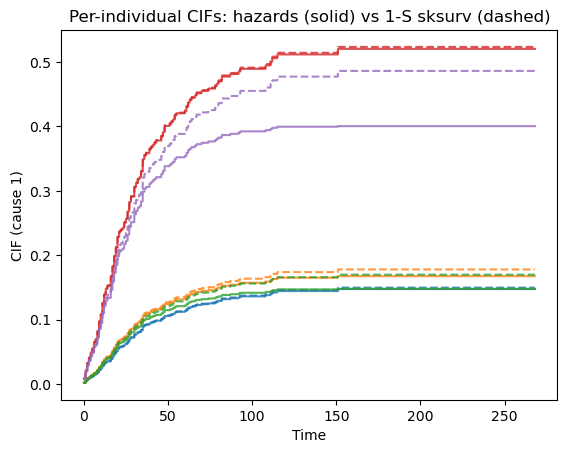

Absolute difference in CIF manual and CIF from sksurv function 0.18421487610967918
Fold 2 (Manual): IBS(cause1)=0.2141 | IBS(cause2)=0.1956


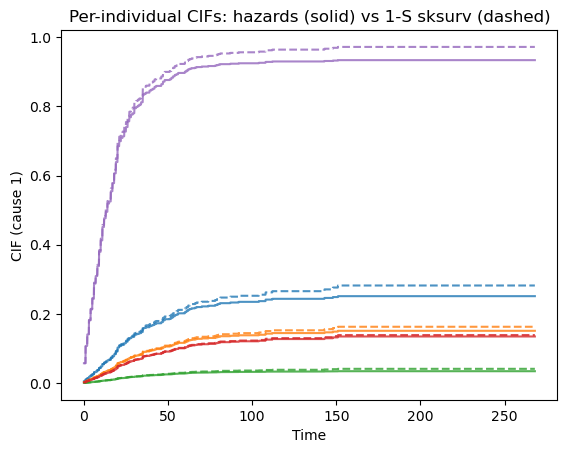

Absolute difference in CIF manual and CIF from sksurv function 0.2973672426027655
Fold 3 (Manual): IBS(cause1)=0.2169 | IBS(cause2)=0.1813


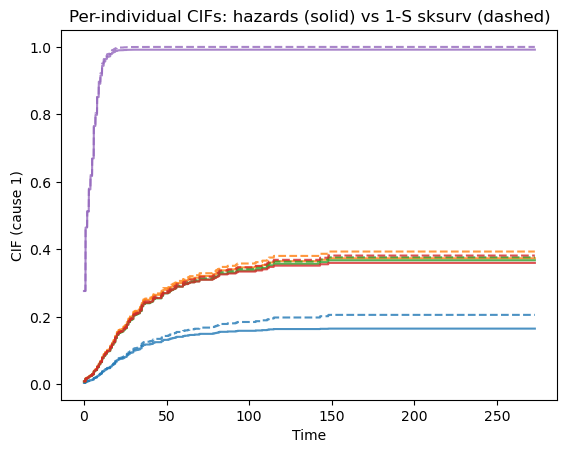

Absolute difference in CIF manual and CIF from sksurv function 0.30598851071447847
Fold 4 (Manual): IBS(cause1)=0.1852 | IBS(cause2)=0.1646


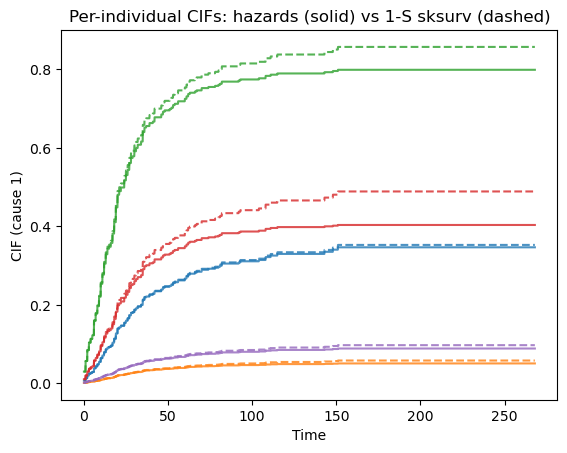

Absolute difference in CIF manual and CIF from sksurv function 0.22753260052187108
Fold 5 (Manual): IBS(cause1)=0.2075 | IBS(cause2)=0.1898


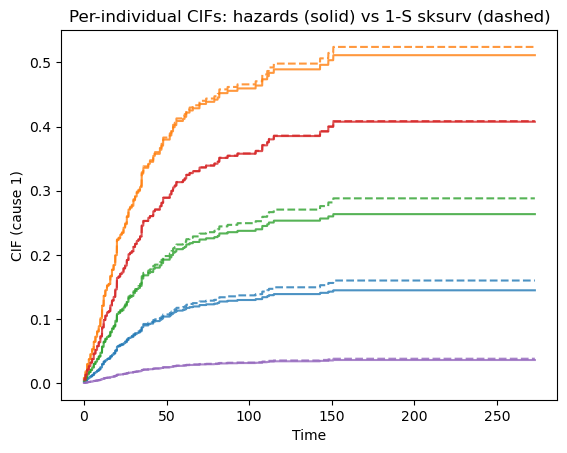

Absolute difference in CIF manual and CIF from sksurv function 0.6610752853576591


In [61]:
ibs_c1_folds, ibs_c2_folds = [], []

base_pre = build_preprocessor(X)  
ct = base_pre.named_steps["pre"]
num_cols = ct.transformers[0][2]  # numeric branch
cat_cols = ct.transformers[1][2]  # categorical branch
print("NUM cols:", len(num_cols), num_cols[:20])
print("CAT cols:", len(cat_cols), cat_cols[:20])

for fold, (train_idx, val_idx) in enumerate(splits, 1):
    
    #print(f"\nFold {fold}")

    X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    t_train, t_val = T_all[train_idx].astype(float), T_all[val_idx].astype(float)
    d_train, d_val = D_all[train_idx].astype(int),   D_all[val_idx].astype(int)

    time_grid = np.arange(0, np.max(t_train), 0.1)

    y_c1 = Surv.from_arrays(event=(d_train == 1), time=t_train)
    y_c2 = Surv.from_arrays(event=(d_train == 2), time=t_train)

    #assert not any(X_train.dtypes == "boolean")
    # cloning the pipe
    #pre = clone(base_pre).fit(X_train)
    pre = clone(base_pre).fit(X_train)

    Xtr = pre.transform(X_train)
    Xva = pre.transform(X_val)

    # adding alpha as regularizer for ridge regression penalty
    cox_1 = CoxPHSurvivalAnalysis(alpha=1.0).fit(Xtr, y_c1)
    cox_2 = CoxPHSurvivalAnalysis(alpha=1.0).fit(Xtr, y_c2)

    # 6) Estimate the cumulative hazard
    m = len(time_grid)
    A1 = cox_1.predict_cumulative_hazard_function(Xva)
    A2 = cox_2.predict_cumulative_hazard_function(Xva)

    # 7) Calculate G_t
    metrics = CompRiskMetricsCompute(
        time_grid=time_grid,
        durations_train=t_train,
        delta_train=d_train,
        eps=0.01
    )
    # To avoid weights blowing up:
    mask = metrics.G_t >= 0.05
    time_grid = time_grid[mask]

    # re-init with trimmed grid
    metrics = CompRiskMetricsCompute(time_grid=time_grid, 
                                     durations_train=t_train, 
                                     delta_train=d_train, 
                                     eps=0.01)
    
    # make it as matrix
    A1_mat = chf_to_matrix(A1, time_grid)   # shape (n_val, m)
    A2_mat = chf_to_matrix(A2, time_grid)

    # 8.1) Calculate the CIFs from the hazards
    F1_pred, F2_pred = cifs_from_cs_hazards(A1_mat, A2_mat)

    # 8.2) We might be able to calculate directly 
    S1_pred = cox_1.predict_survival_function(Xva)
    S2_pred = cox_2.predict_survival_function(Xva)

    S_mat1  = fns_to_matrix(S1_pred, time_grid)        # (n_val, len(time_grid))
    F1_pred_direct = 1.0 - S_mat1

    S_mat2  = fns_to_matrix(S2_pred, time_grid)        # (n_val, len(time_grid))
    F2_pred_direct = 1.0 - S_mat2

    # 9) Calculate the metrics
    ibs_c1 = metrics.integrated_brier_cif(F1_pred, t_val, d_val, cause=1)
    ibs_c2 = metrics.integrated_brier_cif(F2_pred, t_val, d_val, cause=2)

    ibs_c1_folds.append(float(ibs_c1))
    ibs_c2_folds.append(float(ibs_c2))
    print(f"Fold {fold} (Manual): IBS(cause1)={ibs_c1:.4f} | IBS(cause2)={ibs_c2:.4f}")

    # a few individuals
    idx = np.arange(min(5, F1_pred.shape[0]))
    fig, ax = plt.subplots()

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for k, i in enumerate(idx):
        c = colors[k % len(colors)]
        ax.plot(time_grid, F1_pred[i],       color=c, alpha=0.8, label=f"id {i}" if k==0 else None)
        ax.plot(time_grid, F1_pred_direct[i], color=c, ls="--", alpha=0.8)

    ax.set_xlabel("Time")
    ax.set_ylabel("CIF (cause 1)")
    ax.set_title("Per-individual CIFs: hazards (solid) vs 1-S sksurv (dashed)")
    plt.show()


    max_abs_diff = np.max(np.abs(F1_pred - F1_pred_direct))
    print(f"Absolute difference in CIF manual and CIF from sksurv function {max_abs_diff}")





So far ew have done some technical checks. There is less survival analysis functions built in python libraries, so it was necesary to implement some of them. After doing so: 

1. We get the same results (and conclusions) calculating the IBS using our manual functions vs Albergue et at 2025 (in hazardous github). Quite low IBS, which is a good thing. 

2. We get the same IBS using manual set up of preprocessing vs using Pipes from sksurv.

3. CIFs calculated from CoxPH with built in function (1- predict_survival function) vs using manual function give in some cases different curves. 


Double checking correct encoding of categoricals

In [62]:
### double checking correct encoding: 
base_pre = build_preprocessor(X)
pre = clone(base_pre).fit(X) 

ct = pre.named_steps["pre"]
enc = ct.named_transformers_["cat"].named_steps["ohe"]
cat_cols = ct.transformers_[2][2] 



In [63]:
cat_map = dict(zip(cat_cols, enc.categories_))
print(cat_map)

{'MMR_Status': array(['1', '2', '3'], dtype=object), 'Tumour_Location': array(['0', '1', '2'], dtype=object), 'T_Stage': array(['1', '2', '3', '4'], dtype=object), 'N_Stage': array(['0', '1', '2'], dtype=object), 'Histological_Grade': array(['Poor/Undiff', 'Well/Moderate'], dtype=object), 'Elastica_Venous_Invasion': array(['0', '1', '2'], dtype=object)}


In [64]:
ct = pre.named_steps["pre"]

num_cols = ct.transformers_[0][2]
bin_cols = ct.transformers_[1][2]
cat_cols = ct.transformers_[2][2]
enc = ct.named_transformers_["cat"].named_steps["ohe"]

num_out = list(num_cols)                 
bin_out = list(bin_cols) 
cat_out = enc.get_feature_names_out(cat_cols).tolist()

feat_names = np.array(num_out + bin_out + cat_out)

In [65]:
feat_names

array(['Age', 'Tumour_Stroma_Percentage', 'Neutrophils',
       'Preoperative_CRP', 'Preoperative_Albumin',
       'Preoperative_Lymphocytes', 'Lymphoid_Aggregates',
       'Germinal_Centres', 'Intraepithelial_Lymphocytes', 'PTPN12_Tumour',
       'PTPN12_Stroma', 'S100A2_Raw', 'CD3_Raw', 'CD3_FOXP3_Raw',
       'CD68_Raw', 'CXCL9_Raw', 'CXCL10_Raw', 'CyclinD1_Raw',
       'Ki67_Tumour', 'CD163_Stroma', 'CD66b', 'IKK_Alpha_MM',
       'IKK_Beta_MM', 'STAT1_Tumour_Raw', 'BetaCatenin_Cytoplasmic',
       'BetaCatenin_Nuclear', 'BetaCatenin_Membranous',
       'Fascin_Cytoplasmic', 'SMAD4_Cytoplasmic_NS', 'SMAD4_Nuclear_NS',
       'SMAD4_Stroma_Cytoplasmic', 'SMAD4_Stroma_Nuclear', 'NPM1_GK',
       'pSTAT3_Y705_UH', 'Lymph_Node_Ratio', 'Emergency_Surgery', 'Sex',
       'Tumour_Budding', 'Tumour_Perforation', 'Margin_Invasion',
       'Venous_Invasion', 'Peritoneal_Invasion', 'IL6R_AK_186_64',
       'ZEB1_Nuclear', 'Twist_Cytoplasmic', 'Twist_Nuclear',
       'Snail_Cytoplasmic', 'Snai

In [66]:
len(feat_names)

74

Let's focus on adding another model... and looking into shap values. 

#### Explainability

Something very useful would be to use the shap values. It would be great to see how they vary across time SurvShap does that exactly. It might be useful with tree models.

However, in the case of linear model such CoxPH might not be necessary ... but we can look at it.
The baseline input is like the training mean of each feature ($\mu$). And for a linear model:

$$(\phi)_{ij} = (x_{ij} - \mu_{j}) \beta_j$$

So, basically SHAP equals to the coeficient ($\beta$) multiplied by the centered feature. Where each entry $(\phi)_{ij}$ is the contribution of feature j in the sample i to the linear predictor. 

We can then agregate the global inportance, as the mean absolute SHAP across the validation samples, per feature.

In [67]:
# from sklearn 
def shap_linear_val(Xtr_z, Xva_z, beta, feat_names):
    mu  = Xtr_z.mean(axis=0) 
    phi = (Xva_z - mu) * beta # (xij - muj) * betaj
    return pd.Series(np.mean(phi, axis=0), index=feat_names)


Hazard ratios

They are simply the exponential of the coefficients $\beta_j$


In [68]:
def roots_from_ct(pre):
    ct = pre.named_steps["pre"]
    num_roots = []
    cat_roots = []
    for name, trans, cols in ct.transformers_:
        cols = list(cols) if hasattr(cols, "__iter__") and not isinstance(cols, str) else [cols]
        if name == "num": num_roots = cols
        if name == "cat": cat_roots = cols
    return set(num_roots), set(cat_roots)

def group_ohe(gimp, cat_roots, num_roots):
    out = {}
    for name, v in gimp.items():
        base = name.split("=")[0] if "=" in name else name
        root = base if (base in num_roots or base in cat_roots) else \
               next((r for r in cat_roots if base.startswith(r+"_") or base.startswith(r+"=")), base)
        out[root] = out.get(root, 0.0) + float(v)
    return pd.Series(out).sort_values(ascending=False)

In [69]:
len(X.columns)

63

In [70]:
ibs_c1_folds, ibs_c2_folds = [], []
gimp_c1_folds, gimp_c2_folds = [], []
n_val_per_fold = []

base_pre = build_preprocessor(X)  

for fold, (train_idx, val_idx) in enumerate(splits, 1):
    
    #print(f"\nFold {fold}")

    X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    t_train, t_val = T_all[train_idx].astype(float), T_all[val_idx].astype(float)
    d_train, d_val = D_all[train_idx].astype(int),   D_all[val_idx].astype(int)

    y_c1 = Surv.from_arrays(event=(d_train == 1), time=t_train)
    y_c2 = Surv.from_arrays(event=(d_train == 2), time=t_train)

    # cloning the pipe
    pre = clone(base_pre).fit(X_train)

    Xtr = pre.transform(X_train)
    Xva = pre.transform(X_val)

    # adding alpha as regularizer for ridge regression penalty
    # the regularizer really changes the shap
    cox_1 = CoxPHSurvivalAnalysis(alpha=0.5).fit(Xtr, y_c1)
    cox_2 = CoxPHSurvivalAnalysis(alpha=0.5).fit(Xtr, y_c2)

    # getting columns names
    names = pre.named_steps["pre"].get_feature_names_out()
    mask  = pre.named_steps["nzv"].get_support()
    feat_names = np.asarray(names)[mask]
    #print(feat_names)

    # to regroup one-hot into cat
    num_roots, cat_roots = roots_from_ct(pre)

    gimp_c1 = shap_linear_val(Xtr, Xva, cox_1.coef_, feat_names)
    gimp_c2 = shap_linear_val(Xtr, Xva, cox_2.coef_, feat_names)

    gimp_c1_folds.append(group_ohe(gimp_c1, cat_roots, num_roots))
    gimp_c2_folds.append(group_ohe(gimp_c2, cat_roots, num_roots))
    n_val_per_fold.append(len(X_val))



In [71]:
def aggregate_importance(imp_series_list, n_val_per_fold):
    feats = sorted(set().union(*[s.index for s in imp_series_list]))
    M = pd.DataFrame({i: s.reindex(feats).fillna(0.0) for i, s in enumerate(imp_series_list)}, index=feats)
    w = np.asarray(n_val_per_fold, float); w = w / w.sum()
    return M.dot(w).sort_values(ascending=False)

def plot_importance(imp, title, k=20):
    top = imp.head(k).iloc[::-1]
    plt.figure(figsize=(12,8))
    plt.barh(top.index, top.values)
    plt.xlabel("Mean |SHAP| on risk score (OOF)")
    plt.title(title)
    plt.tight_layout(); plt.show()

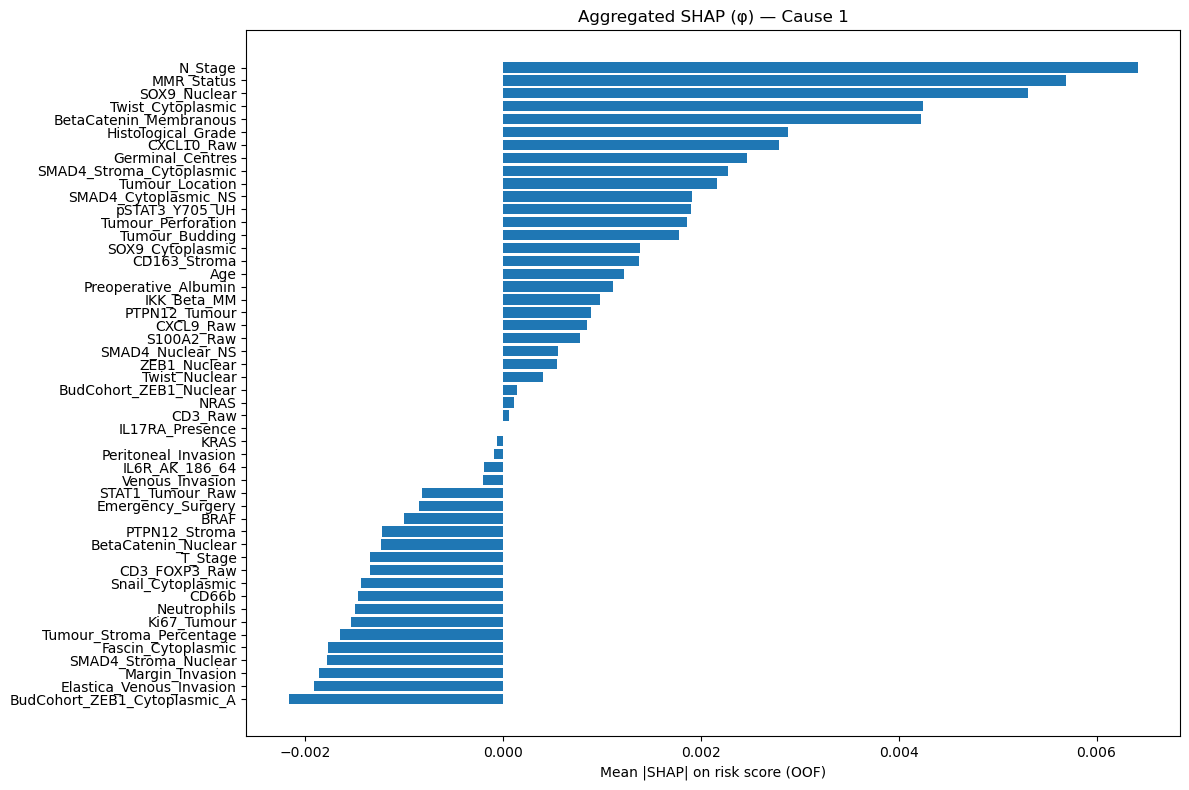

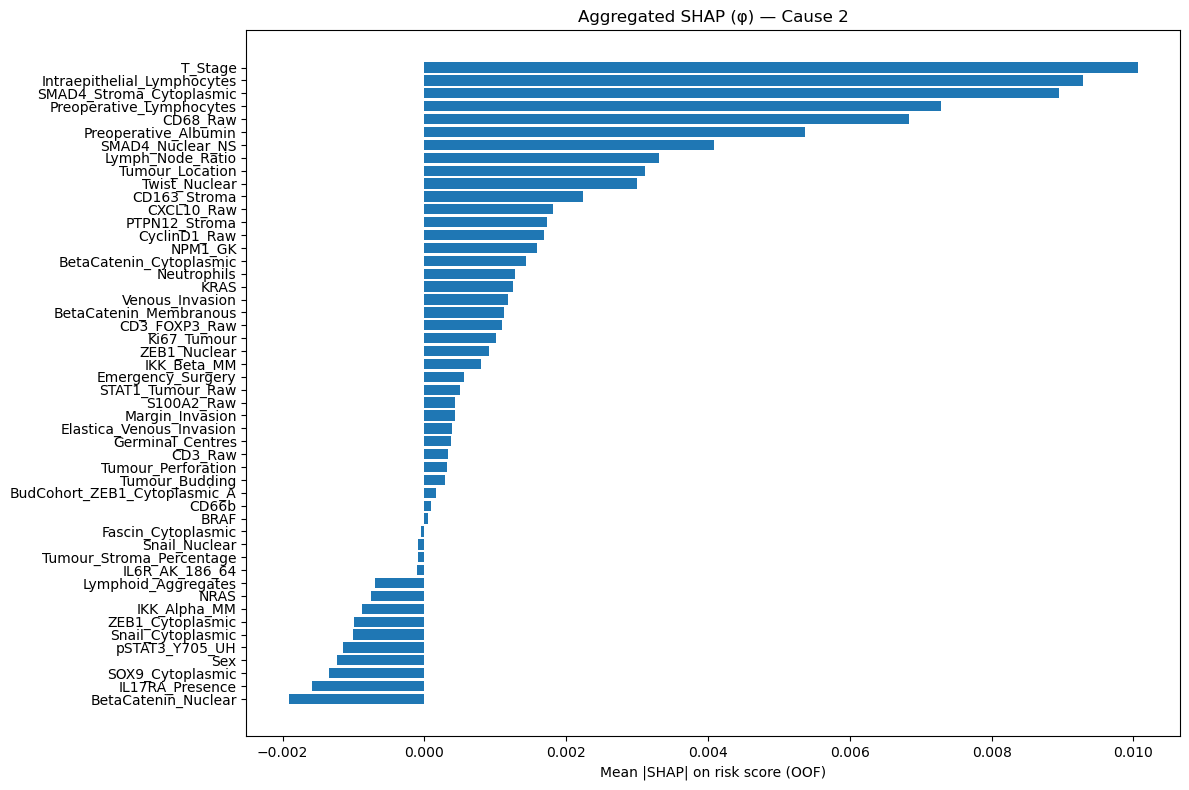

In [72]:
agg_c1 = aggregate_importance(gimp_c1_folds, n_val_per_fold)
agg_c2 = aggregate_importance(gimp_c2_folds, n_val_per_fold)

plot_importance(agg_c1, "Aggregated SHAP (φ) — Cause 1", k=50)
plot_importance(agg_c2, "Aggregated SHAP (φ) — Cause 2", k=50)


In [73]:
# might be useful for other models with no PH and non-linear
from survshap import SurvivalModelExplainer, PredictSurvSHAP, ModelSurvSHAP
import shap

/opt/homebrew/Caskroom/miniforge/base/envs/GRIsurv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Compared with qpis

How much better better/worse are the predictions with just the qpis?


In [74]:
qpis = [
    "MMR_Status","BRAF","Sex","Tumour_Location",
    "T_Stage","N_Stage","Histological_Grade","Lymph_Node_Ratio","Margin_Invasion",
    "Disease_Free_Survival_Months","Cmprsk_Status", "Age"
]

df_qpis = df.loc[X.index, qpis].copy()  

# Features / targets for the subset dataset
X_small = df_qpis.drop(columns=["Disease_Free_Survival_Months", "Cmprsk_Status"])
T_small = df_qpis["Disease_Free_Survival_Months"].to_numpy(float)
D_small = df_qpis["Cmprsk_Status"].to_numpy(int)


In [75]:
len(X_small.columns)

10

In [76]:
### maybe just in function

def run_cv_ibs(X_df, T_all, D_all, splits, base_pre,
               epsG=0.01, Gmin=0.05, alpha=1.0):
    ibs_c1, ibs_c2, n_val = [], [], []

    for (train_idx, val_idx) in splits:
        X_train, X_val = X_df.iloc[train_idx], X_df.iloc[val_idx]
        t_train, t_val = T_all[train_idx].astype(float), T_all[val_idx].astype(float)
        d_train, d_val = D_all[train_idx].astype(int),   D_all[val_idx].astype(int)

        # preprocessor
        pre = clone(base_pre).fit(X_train)
        Xtr, Xva = pre.transform(X_train), pre.transform(X_val)

        # cause-specific Cox
        y_c1 = Surv.from_arrays(event=(d_train==1), time=t_train)
        y_c2 = Surv.from_arrays(event=(d_train==2), time=t_train)
        cox_1 = CoxPHSurvivalAnalysis(alpha=alpha).fit(Xtr, y_c1)
        cox_2 = CoxPHSurvivalAnalysis(alpha=alpha).fit(Xtr, y_c2)

        # 6) Estimate the cumulative hazard
        A1 = cox_1.predict_cumulative_hazard_function(Xva)
        A2 = cox_2.predict_cumulative_hazard_function(Xva)

        t_event_max = np.max(t_train[d_train != 0]) if np.any(d_train != 0) else np.max(t_train)
        raw_grid = np.arange(0.0, max(t_event_max, 1e-8), 0.1)

        probe = CompRiskMetricsCompute(time_grid=raw_grid, durations_train=t_train, delta_train=d_train, eps=0.01)
        mask = probe.G_t >= 0.05
        time_grid = raw_grid[mask] if np.any(mask) else raw_grid[:min(10, raw_grid.size)]
        metrics = CompRiskMetricsCompute(time_grid=time_grid, durations_train=t_train, delta_train=d_train, eps=0.01)

        # CIFs
        A1_mat = chf_to_matrix(A1, time_grid)
        A2_mat = chf_to_matrix(A2, time_grid)
        F1_pred, F2_pred = cifs_from_cs_hazards(A1_mat, A2_mat)

        # IBS per cause
        ibs1 = metrics.integrated_brier_cif(F1_pred, t_val, d_val, cause=1)
        ibs2 = metrics.integrated_brier_cif(F2_pred, t_val, d_val, cause=2)

        ibs_c1.append(float(ibs1)); ibs_c2.append(float(ibs2))
        n_val.append(len(X_val))

    return np.array(ibs_c1), np.array(ibs_c2), np.array(n_val)


In [77]:
ibs_c1_folds, ibs_c2_folds = [], []
ibs_c1_folds_small, ibs_c2_folds_small = [], []

base_pre = build_preprocessor(X)  
base_pre_small = build_preprocessor(X_small) 


ibs1_full, ibs2_full, nval_full = run_cv_ibs(X,        
                                             T_all,  
                                             D_all,  
                                             splits, 
                                             base_pre,
                                             alpha=1)

ibs1_sub,  ibs2_sub,  nval_sub  = run_cv_ibs(X_small,  
                                             T_small, 
                                             D_small, 
                                             splits, 
                                             base_pre_small,
                                             alpha=1)



In [78]:
ibs1_full

array([0.21136197, 0.21403914, 0.2103205 , 0.18515706, 0.20702119])

In [79]:
ibs1_sub

array([0.18860151, 0.1947295 , 0.19207596, 0.17139272, 0.19961385])

Suggests that in all cases the IBS is better with the small dataset. 

In [80]:
np.mean(ibs1_sub) - np.mean(ibs1_full)


np.float64(-0.016297264094876474)

In [81]:
np.mean(ibs2_sub) - np.mean(ibs2_full)


np.float64(-0.013331466044876172)

In [82]:
np.mean(ibs1_full)

np.float64(0.2055799713055672)

In [83]:
np.mean(ibs1_sub)

np.float64(0.18928270721069074)

In [84]:
def lifelines_hr_ci_from_matrix(Xtr, t_train, d_train, cause, feat_names, penalizer=1.0, robust=True):
    """Fit lifelines Cox on (already preprocessed) TRAIN matrix to get HR & 95% CI."""
    df = pd.DataFrame(Xtr, columns=feat_names)
    df["__time__"]  = t_train.astype(float)
    df["__event__"] = (d_train == cause).astype(int)
    cph = CoxPHFitter(penalizer=penalizer)
    cph.fit(df, duration_col="__time__", event_col="__event__", robust=robust)
    s = cph.summary 
    out = pd.DataFrame({
        "HR": s["exp(coef)"],
        "CI_low": s["exp(coef) lower 95%"],
        "CI_high": s["exp(coef) upper 95%"],
    })
    return out.sort_index(), cph 

def forest_plot_from_table(tbl, title="Hazard ratios"):
    hr, lo, hi = tbl["HR"].to_numpy(), tbl["CI_low"].to_numpy(), tbl["CI_high"].to_numpy()
    labels = tbl.index.tolist()
    order = np.argsort(hr)  
    hr, lo, hi = hr[order], lo[order], hi[order]
    labels = [labels[i] for i in order]
    y = np.arange(len(hr))
    plt.figure(figsize=(6.5, 0.4*len(hr)+1))
    plt.hlines(y, lo, hi, lw=2)
    plt.plot(hr, y, "o")
    plt.vlines(1.0, -1, len(hr), linestyles="dashed", color="gray")
    plt.yticks(y, labels)
    plt.xscale("log"); plt.xlabel("Hazard ratio"); plt.title(title)
    plt.tight_layout(); plt.show()

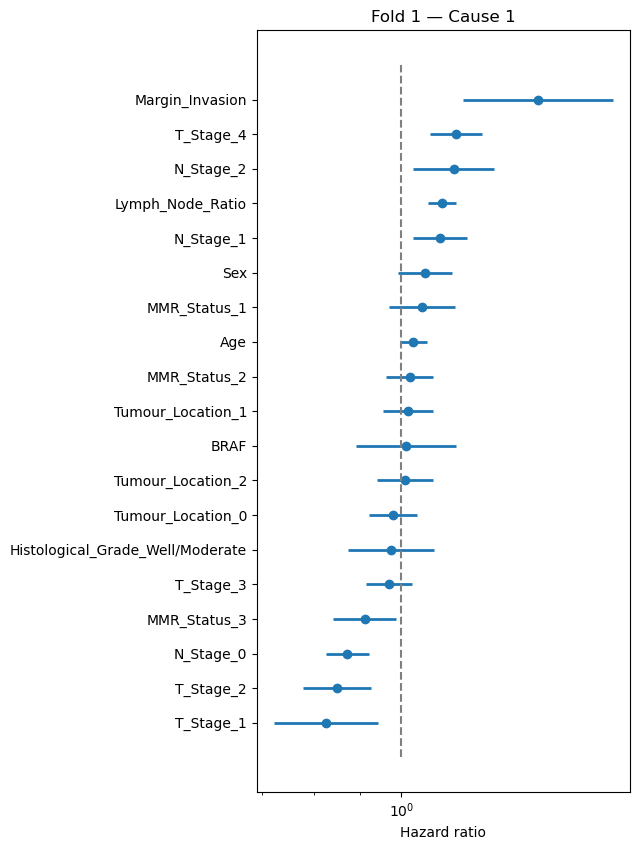

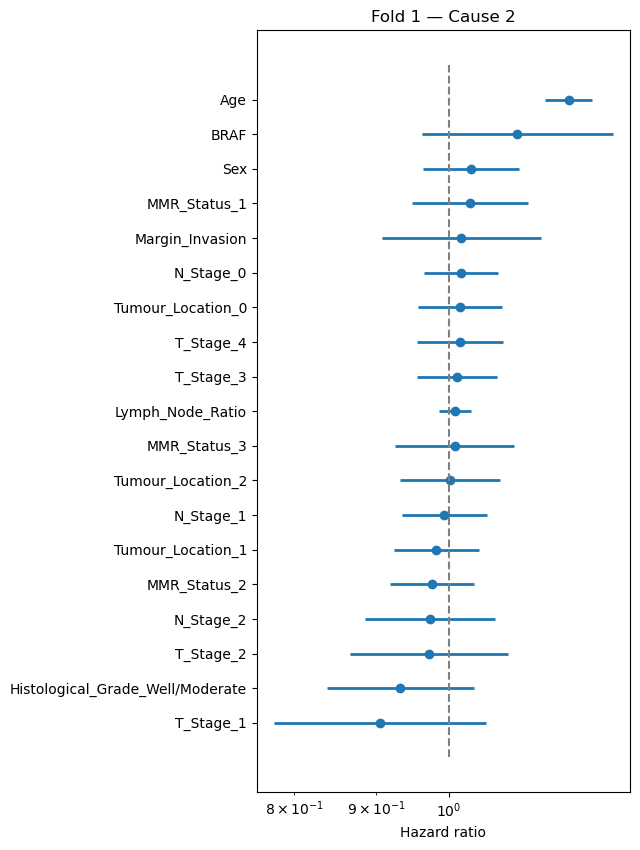

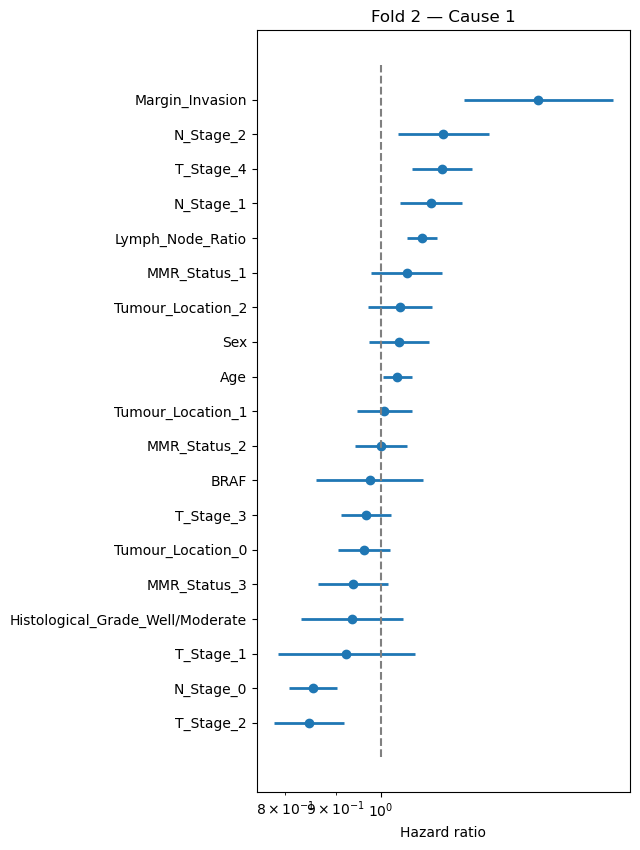

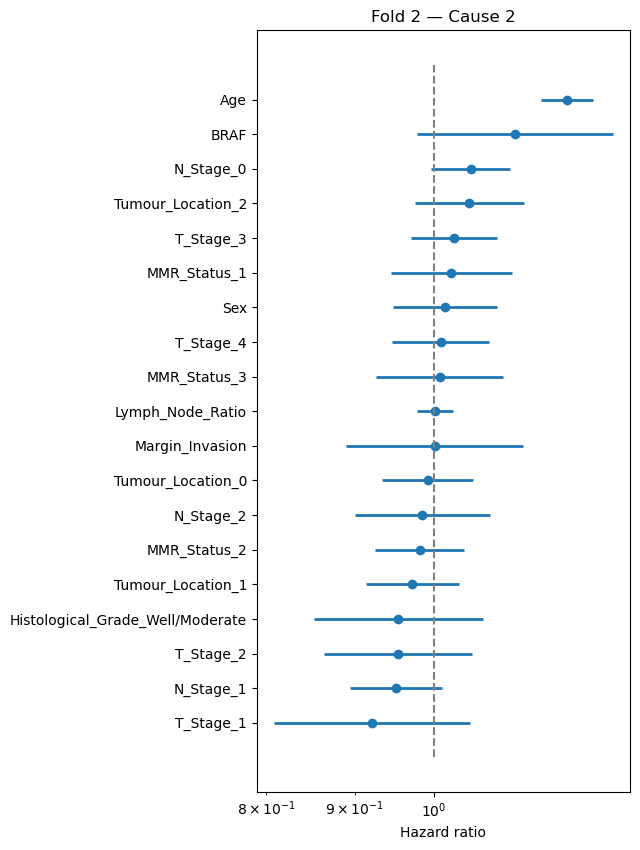

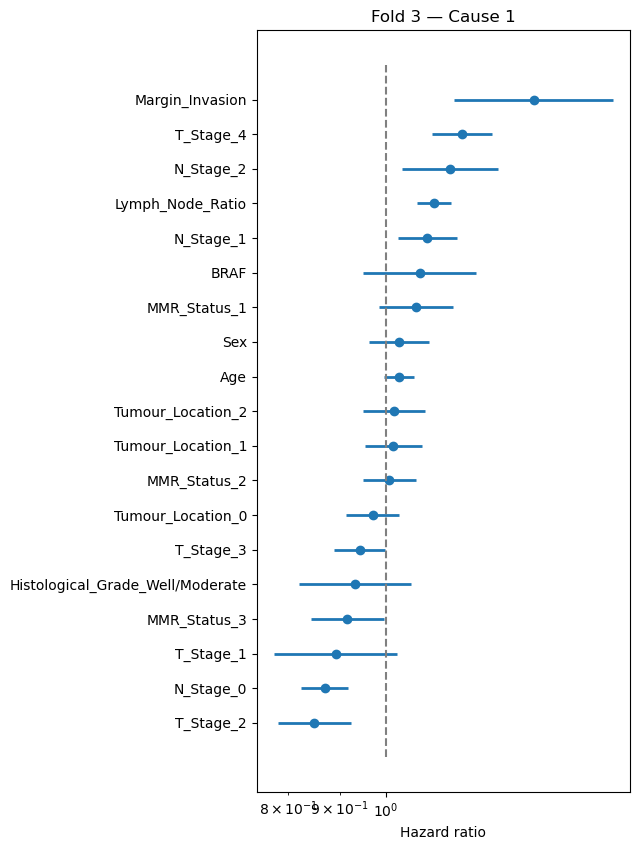

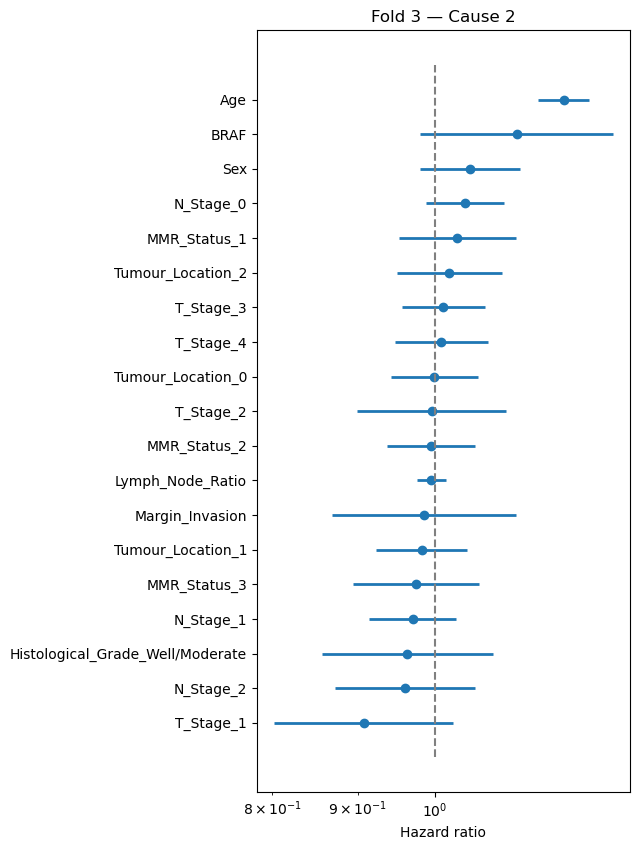

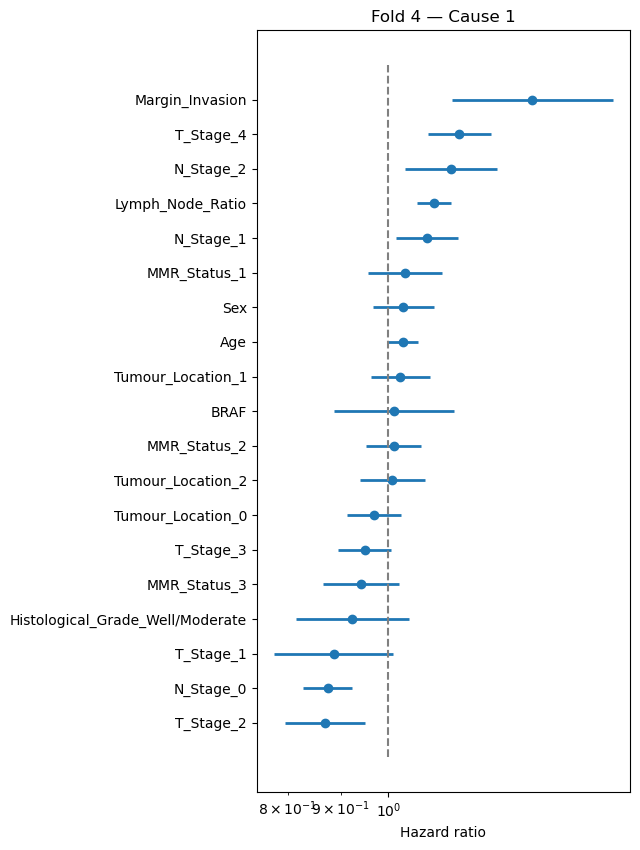

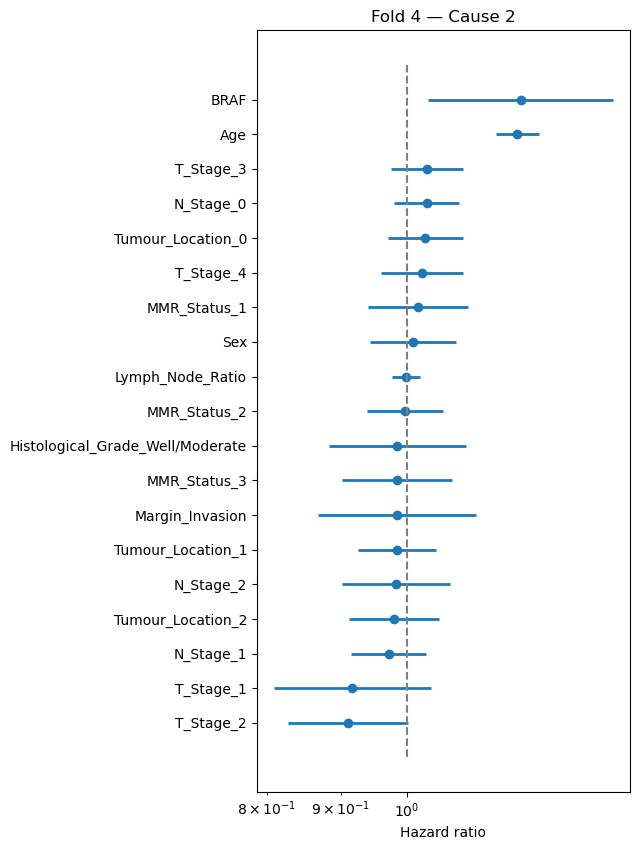

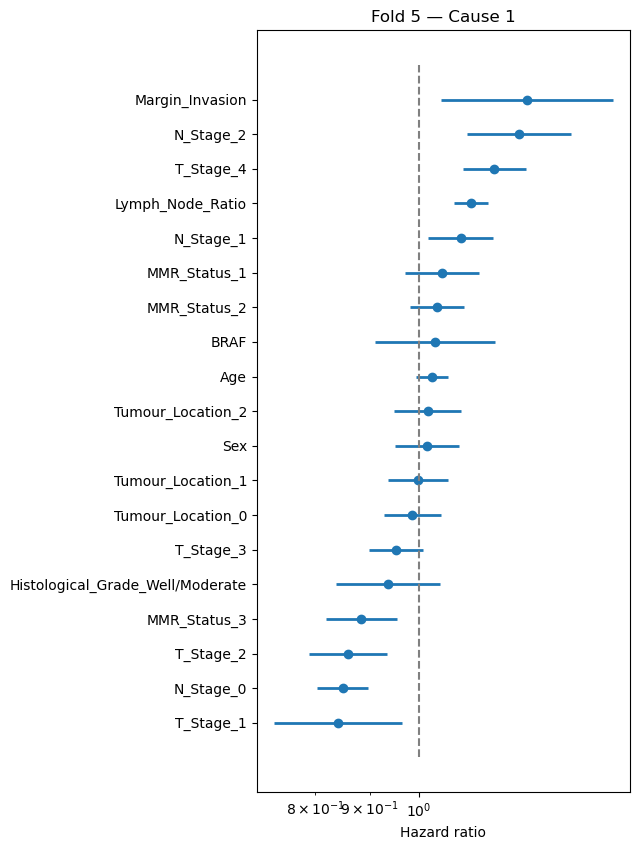

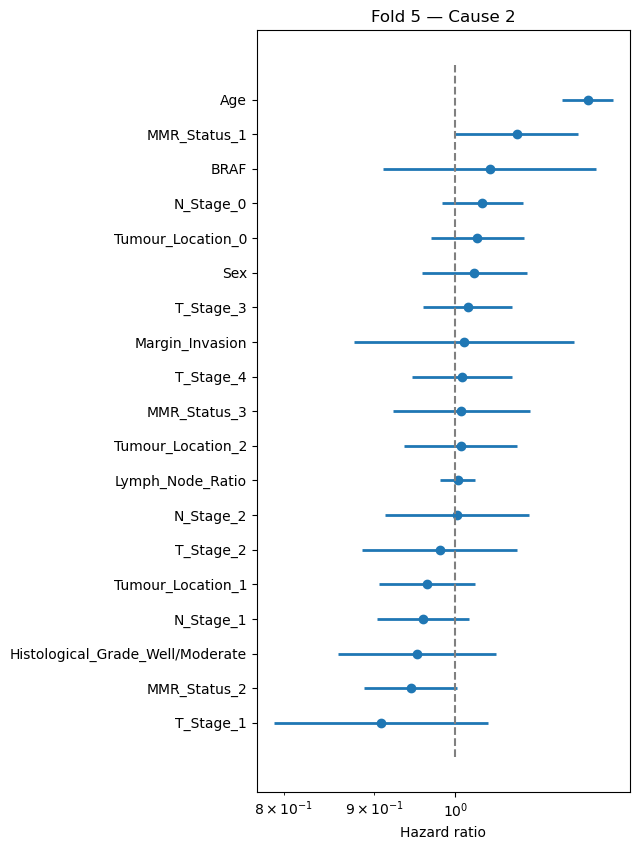

In [85]:
ibs_c1_folds, ibs_c2_folds = [], []
gimp_c1_folds, gimp_c2_folds = [], []
hrtab_c1_folds, hrtab_c2_folds = [] , [] 
n_val_per_fold = []

base_pre = build_preprocessor(X_small)  

for fold, (train_idx, val_idx) in enumerate(splits, 1):

    X_train, X_val = X_small.iloc[train_idx].copy(), X_small.iloc[val_idx].copy()
    t_train, t_val = T_small[train_idx].astype(float), T_small[val_idx].astype(float)   # if labels differ, use T_small/D_small
    d_train, d_val = D_small[train_idx].astype(int),   D_small[val_idx].astype(int)

    pre = clone(base_pre).fit(X_train)
    Xtr = pre.transform(X_train)
    Xva = pre.transform(X_val)

    y_c1 = Surv.from_arrays(event=(d_train == 1), time=t_train)
    y_c2 = Surv.from_arrays(event=(d_train == 2), time=t_train)
    cox1 = CoxPHSurvivalAnalysis(alpha=1.0).fit(Xtr, y_c1)
    cox2 = CoxPHSurvivalAnalysis(alpha=1.0).fit(Xtr, y_c2)

    t_event_max = np.max(t_train[d_train != 0]) if np.any(d_train != 0) else np.max(t_train)
    raw_grid = np.arange(0.0, max(t_event_max, 1e-8), 0.1)

    probe = CompRiskMetricsCompute(time_grid=raw_grid, durations_train=t_train, delta_train=d_train, eps=0.01)
    mask = probe.G_t >= 0.05
    time_grid = raw_grid[mask] if np.any(mask) else raw_grid[:min(10, raw_grid.size)]
    metrics = CompRiskMetricsCompute(time_grid=time_grid, durations_train=t_train, delta_train=d_train, eps=0.01)
    
    # get feature names
    names = pre.named_steps["pre"].get_feature_names_out()
    mask  = pre.named_steps["nzv"].get_support()
    feat_names = np.asarray(names)[mask]

    # casuse-specififc with Lifelines
    hrtab_c1, cph1 = lifelines_hr_ci_from_matrix(Xtr, t_train, d_train, cause=1,
                                                feat_names=feat_names, penalizer=1.0, robust=True)
    hrtab_c2, cph2 = lifelines_hr_ci_from_matrix(Xtr, t_train, d_train, cause=2,
                                                feat_names=feat_names, penalizer=1.0, robust=True)
    hrtab_c1_folds.append(hrtab_c1)
    hrtab_c2_folds.append(hrtab_c2)

    forest_plot_from_table(hrtab_c1, title=f"Fold {fold} — Cause 1")
    forest_plot_from_table(hrtab_c2, title=f"Fold {fold} — Cause 2")

    A1 = cox1.predict_cumulative_hazard_function(Xva)
    A2 = cox2.predict_cumulative_hazard_function(Xva)
    A1_mat = chf_to_matrix(A1, time_grid)
    A2_mat = chf_to_matrix(A2, time_grid)
    F1_pred, F2_pred = cifs_from_cs_hazards(A1_mat, A2_mat)

    ibs_c1 = metrics.integrated_brier_cif(F1_pred, t_val, d_val, cause=1)
    ibs_c2 = metrics.integrated_brier_cif(F2_pred, t_val, d_val, cause=2)
    ibs_c1_folds.append(float(ibs_c1))
    ibs_c2_folds.append(float(ibs_c2))

    names_all = pre.named_steps["pre"].get_feature_names_out()
    kept_mask = pre.named_steps["nzv"].get_support()
    feat_names = np.asarray(names_all)[kept_mask]
    num_roots, cat_roots = roots_from_ct(pre)

    gimp_c1 = shap_linear_val(Xtr, Xva, cox1.coef_, feat_names)
    gimp_c2 = shap_linear_val(Xtr, Xva, cox2.coef_, feat_names)
    gimp_c1_folds.append(group_ohe(gimp_c1, cat_roots, num_roots))
    gimp_c2_folds.append(group_ohe(gimp_c2, cat_roots, num_roots))

    n_val_per_fold.append(len(X_val))



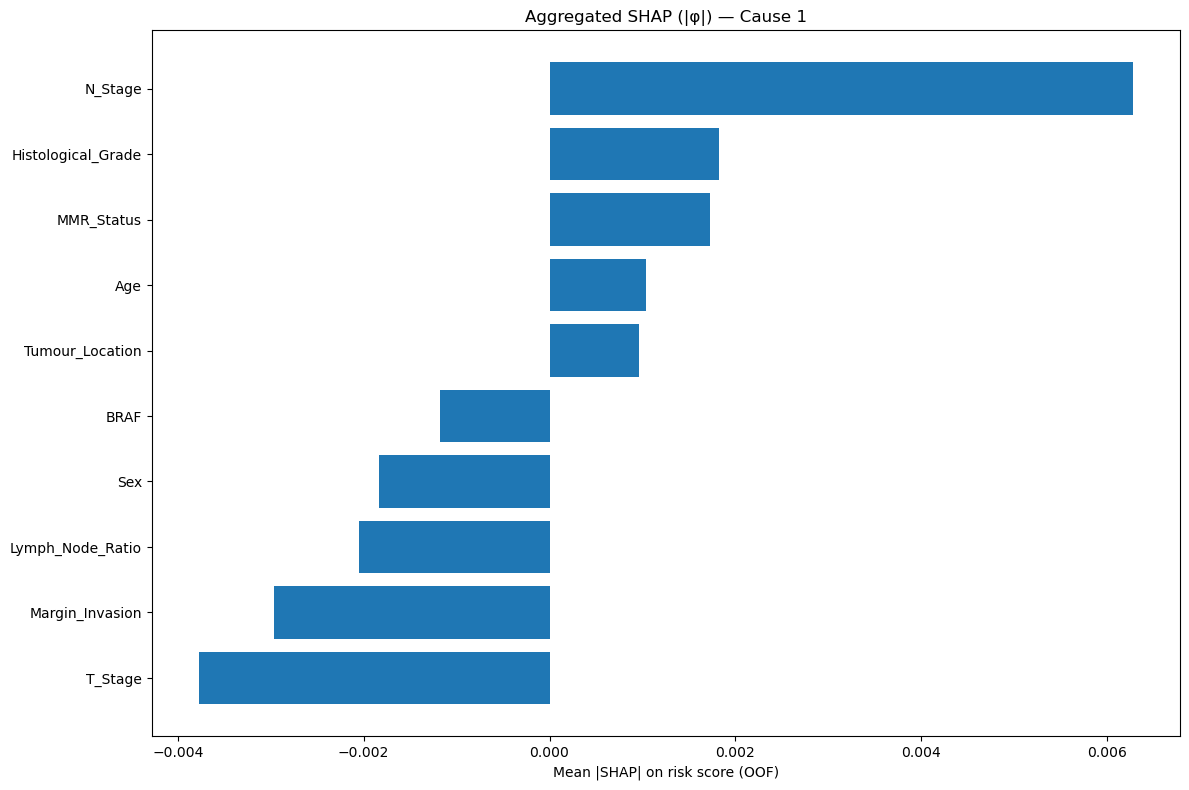

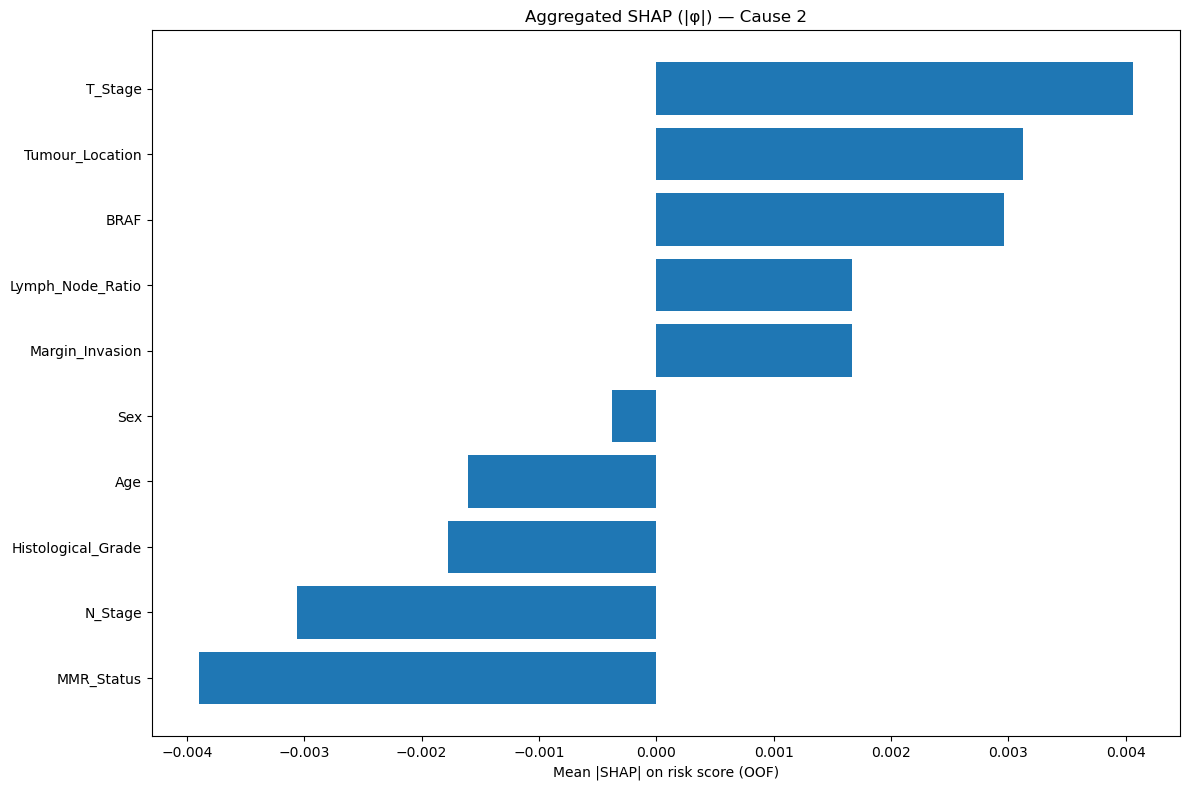

In [86]:
agg_c1 = aggregate_importance(gimp_c1_folds, n_val_per_fold)
agg_c2 = aggregate_importance(gimp_c2_folds, n_val_per_fold)

plot_importance(agg_c1, "Aggregated SHAP (|φ|) — Cause 1", k=20)
plot_importance(agg_c2, "Aggregated SHAP (|φ|) — Cause 2", k=20)

### why these results... 

1. Lots of covariates in the bigger dataset, collinearity ? Sparsity?

2. Might be some problematic imputation?

3. Maybe try permutation to see which variables are hurting? 

4. Maybe some inner fold to determine the hyperparameter alpha in ridge cox ph 